In [1]:
import sys
print("Python Path:", sys.executable)

import tensorflow as tf
import torch
import cv2
import numpy as np
from ultralytics import YOLO

print("TensorFlow:", tf.__version__)
print("Torch:", torch.__version__)
print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)

print("Environment Ready ✅")

Python Path: C:\Users\basil\anaconda3\envs\mlops_cnn\python.exe

TensorFlow: 2.15.0
Torch: 2.8.0+cpu
OpenCV: 4.8.1
NumPy: 1.26.4
Environment Ready ✅


In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [4]:
train_dir="data/training"

generator = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

train_ds = generator.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32
)

classes = list(train_ds.class_indices.keys())

Found 1383 images belonging to 3 classes.


In [5]:
val_gen = ImageDataGenerator(rescale=1./255)

val_ds = val_gen.flow_from_directory(
    "data/validation",
    target_size=(224,224),
    batch_size=32
)

Found 248 images belonging to 3 classes.


In [6]:
model = Sequential()
model.add(Conv2D(32, kernel_size = (3, 3), activation='relu', input_shape=(224,224,3)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(BatchNormalization())
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(BatchNormalization())
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(BatchNormalization())
model.add(Conv2D(96, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(BatchNormalization())
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
#model.add(Dropout(0.3))
model.add(Dense(len(classes),activation='softmax'))

In [7]:
model.compile(
    loss = 'categorical_crossentropy',
    optimizer = 'adam',
    metrics = ["accuracy"])
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 111, 111, 32)      0         
 D)                                                              
                                                                 
 batch_normalization (Batch  (None, 111, 111, 32)      128       
 Normalization)                                                  
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 54, 54, 64)        0         
 g2D)                                                            
                                                       

In [8]:
history = model.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds
)

Epoch 1/30


44/44 [==============================] - 72s 2s/step - loss: 1.2959 - accuracy: 0.4382 - val_loss: 1.3260 - val_accuracy: 0.3306
Epoch 2/30
44/44 [==============================] - 57s 1s/step - loss: 1.0472 - accuracy: 0.5076 - val_loss: 2.8626 - val_accuracy: 0.3306
Epoch 3/30
44/44 [==============================] - 51s 1s/step - loss: 0.9447 - accuracy: 0.5719 - val_loss: 2.1125 - val_accuracy: 0.3306
Epoch 4/30
44/44 [==============================] - 44s 1s/step - loss: 0.8964 - accuracy: 0.5734 - val_loss: 3.0249 - val_accuracy: 0.3306
Epoch 5/30
44/44 [==============================] - 45s 1s/step - loss: 0.8657 - accuracy: 0.5958 - val_loss: 2.0301 - val_accuracy: 0.3629
Epoch 6/30
44/44 [==============================] - 63s 1s/step - loss: 0.8207 - accuracy: 0.6117 - val_loss: 2.0957 - val_accuracy: 0.3347
Epoch 7/30
44/44 [==============================] - 49s 1s/step - loss: 0.8137 - accuracy: 0.6276 - val_loss: 1.8597 - val_accuracy: 0.3387
Epoch 8/30
44/44 [

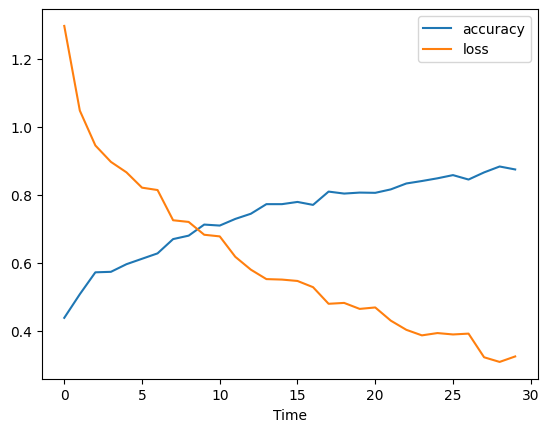

In [9]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['loss'])
plt.xlabel('Time')
plt.legend(['accuracy', 'loss'])
plt.show()

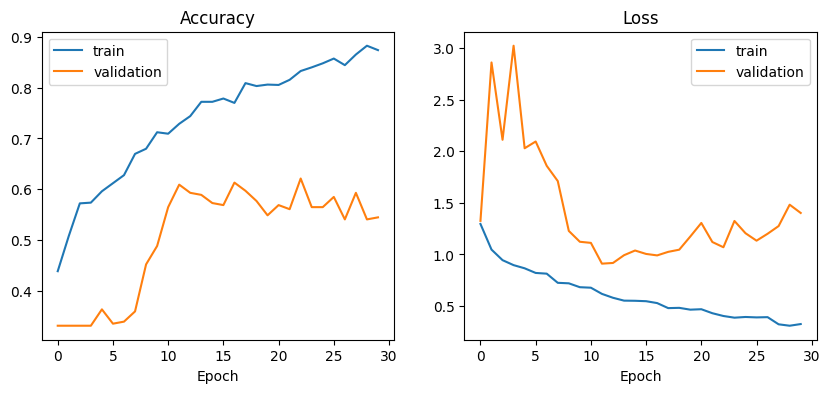

In [10]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend(["train","validation"])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend(["train","validation"])

plt.show()

In [17]:
def predict_image(image_path):
    
    img = image.load_img(image_path, target_size=(224,224))
    
    plt.imshow(img)
    plt.axis("off")
    plt.show()
    
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    
    pred = model.predict(x)
    
    predicted_class = classes[np.argmax(pred)]
    
    print("Actual:", image_path.split("/")[-2])
    print("Predicted:", predicted_class)
    

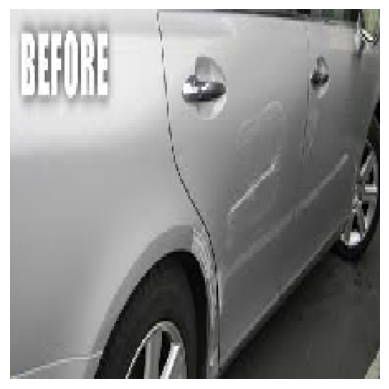

1/1 [==============================] - 0s 49ms/step
Actual: 01-minor
Predicted: 02-moderate


In [25]:
predict_image("data/validation/01-minor/0048.jpeg")

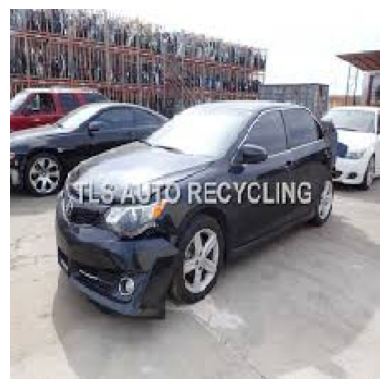

1/1 [==============================] - 0s 63ms/step
Actual: 02-moderate
Predicted: 03-severe


In [26]:
predict_image("data/validation/02-moderate/0032.jpeg")

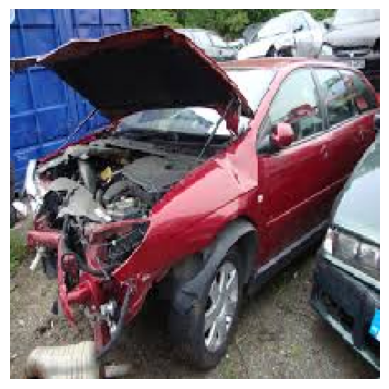

1/1 [==============================] - 0s 44ms/step
Actual: 03-severe
Predicted: 03-severe


In [21]:
predict_image("data/validation/03-severe/0035.jpeg")

In [27]:
# serialize model to JSON
model_json = model.to_json()

with open("model.json", "w") as json_file:
    json_file.write(model_json)

# save weights
model.save('car.h5')

print("Model saved successfully")

C:\Users\basil\anaconda3\envs\mlops_cnn\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Model saved successfully


In [28]:
from tensorflow.keras.models import load_model

model = load_model('car.h5')

print("Model loaded successfully")

Model loaded successfully


In [ ]:
from tensorflow.keras.models import load_model # load saved model
model = load_model('car.h5')

In [ ]:
def predict_image(image_path):
    img = image.load_img(image_path, target_size=(224,224,3))
    plt.imshow(img)
    plt.show()
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    images = np.vstack([x])
    pred = model.predict(images, batch_size=32)
    
    print("Actual: "+(image_path.split("/")[-2]).split("_")[0])
    print("Predicted: "+classes[np.argmax(pred)])
    predicted_class = classes[np.argmax(pred)]
    predict_image("Dataset/thumbs_up/564.jpg")

In [ ]:
from flask import Flask, render_template, request
from tensorflow.keras.models import load_model
import numpy as np
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.applications.vgg16 import preprocess_input
import os
import tensorflow
from tensorflow.keras.preprocessing import image

app = Flask(__name__)
model = load_model('car.h5')
target_img = os.path.join(os.getcwd() , 'static/images')

@app.route('/')
def index_view():
    return render_template('index.html')

#Allow files with extension png, jpg and jpeg
ALLOWED_EXT = set(['jpg' , 'jpeg' , 'png'])
def allowed_file(filename):
    return '.' in filename and \
           filename.rsplit('.', 1)[1] in ALLOWED_EXT
           
# Function to load and prepare the image in right shape
def read_image(filename):

    img = load_img(filename, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    return x

@app.route('/predict',methods=['GET','POST'])
def predict():
    if request.method == 'POST':
        file = request.files['file']
        if file and allowed_file(file.filename):
            filename = file.filename
            file_path = os.path.join('static/images', filename)
            file.save(file_path)
            img = read_image(file_path)
            img = image.load_img(file_path, target_size=(224, 224))
            img_array = image.img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0)  # Expand to batch dimension
            
            class_prediction=model.predict(img_array) 
            classes_x=np.argmax(class_prediction, axis=1)[0]
            dataset = tensorflow.keras.preprocessing.image_dataset_from_directory("data/training")
            class_names = dataset.class_names 
            predicted_class = class_names[classes_x]
            print(f"Predicted Class: {predicted_class}")

            
            return render_template('predict.html', fruit = predicted_class,prob=class_prediction, user_image = file_path)
        else:
            return "Unable to read the file. Please check file extension"

if __name__ == '__main__':
    app.run(debug=True,use_reloader=False, port=8000)

In [ ]:
!pip install ultralytics

In [ ]:
import os
import shutil
from PIL import Image
from tqdm import tqdm
from ultralytics import YOLO

In [ ]:
# Diretórios de entrada
source_root = "data"
target_root = "car_damage_yolo"

# Mapeamento de classes
class_mapping = {
    "01-minor": 0,
    "02-moderate": 1,
    "03-severe": 2
}

# Criação da estrutura YOLO (images/ e labels/)
for split in ["train", "val"]:
    os.makedirs(f"{target_root}/images/{split}", exist_ok=True)
    os.makedirs(f"{target_root}/labels/{split}", exist_ok=True)

    for class_folder in class_mapping.keys():
        class_id = class_mapping[class_folder]
        img_dir = os.path.join(source_root, "training" if split=="train" else "validation", class_folder)
        img_files = [f for f in os.listdir(img_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]

        for img_file in tqdm(img_files, desc=f"{split} - {class_folder}"):
            src_img = os.path.join(img_dir, img_file)
            dst_img = os.path.join(f"{target_root}/images/{split}", img_file)
            dst_txt = os.path.join(f"{target_root}/labels/{split}", img_file.rsplit(".", 1)[0] + ".txt")

            # Copia imagem
            shutil.copyfile(src_img, dst_img)

            # Cria bounding box central (falsa)
            with Image.open(src_img) as im:
                w, h = im.size
            x_center, y_center = 0.5, 0.5
            box_width, box_height = 0.8, 0.8

            with open(dst_txt, "w") as f:
                f.write(f"{class_id} {x_center} {y_center} {box_width} {box_height}\n")

In [ ]:
data_yaml = """
path: car_damage_yolo
train: images/train
val: images/val

names:
  0: minor
  1: moderate
  2: severe
"""

with open("car_damage_yolo/data.yaml", "w") as f:
    f.write(data_yaml)

In [ ]:
# Modelo yolo
model = YOLO("yolov8n-seg.pt")  # ou yolov8s.pt para versão mais robusta

In [ ]:
yolo task=detect mode=train model=yolov8n.pt data=data.yaml epochs=50 imgsz=640

In [ ]:
# Treinamento modelo
model.train(data="car_damage_yolo/data.yaml",
            epochs=5,
            imgsz=640,
            batch=16,
            name="car_damage_detector")


In [ ]:
# Usar melhor modelo após treino
model = YOLO("runs/detect/car_damage_detector3/weights/best.pt")

# Prever em uma imagem da validação
results = model.predict(source="car_damage_yolo/images/val", 
                        conf=0.10,
                        save=True)

In [ ]:
from IPython.display import Image, display
import glob

predicted_images = glob.glob('runs/detect/predict5/*.jpg')

for img_path in predicted_images[:100]:
    display(Image(filename=img_path))

In [ ]:
from ultralytics import YOLO
from PIL import Image
from IPython.display import display
from glob import glob
import os

# Lista de caminhos das 3 imagens para prever
img_paths = [
    "data/validation/01-minor/0004.JPEG",
    "data/validation/02-moderate/0015.jpeg",
    "data/validation/03-severe/0028.JPEG"
]

# Carregar o modelo YOLO treinado (ajuste o caminho se necessário)
model = YOLO("runs/detect/car_damage_detector3/weights/best.pt")

In [ ]:
# Loop para prever e mostrar cada imagem
for img_path in img_paths:
    print(f"Fazendo predição para: {img_path}")
    
    results = model.predict(source=img_path, conf=0.4, save=True)

    # Buscar imagem salva com boxes
    saved_imgs = glob(f"{results[0].save_dir}/*.jpg") + \
                 glob(f"{results[0].save_dir}/*.jpeg") + \
                 glob(f"{results[0].save_dir}/*.png")
    
    if saved_imgs:
        display(Image.open(saved_imgs[-1]))  # sempre pega a última gerada
    else:
        print("Nenhuma imagem salva para essa predição.")